# Sharing and Importing Tools

In this notebook, I explore how tools can be shared and reused using the Hugging Face `smolagents` library.

I will learn how to:

- Share a custom tool on the Hugging Face Hub
- Import an existing tool from the Hugging Face Hub
- Use a Hugging Face Space as a tool
- Explore integration with LangChain tools
- Explore MCP tool collections

## 1. Preparing a Custom Tool

Before sharing a tool on the Hugging Face Hub, we first need to create or instantiate the custom tool that we want to share.

In this example, I will use a custom `SuperheroPartyThemeTool` that generates superhero-themed party ideas based on a given category.

In [1]:
from smolagents import Tool, CodeAgent, InferenceClientModel

class SuperheroPartyThemeTool(Tool):
    name = "superhero_party_theme_generator"

    description = """
    This tool suggests creative superhero-themed party ideas based on a category.
    """

    inputs = {
        "category": {
            "type": "string",
            "description": "The type of superhero party."
        }
    }

    output_type = "string"

    def forward(self, category: str):
        themes = {
            "classic heroes": "Justice League Gala with superhero costumes and themed drinks.",
            "villain masquerade": "Gotham Rogues' Ball where guests dress as famous villains.",
            "futuristic gotham": "Neo-Gotham Night with cyberpunk decorations and futuristic gadgets."
        }

        return themes.get(
            category.lower(),
            "Theme not found."
        )

## 2. Instantiating and Testing the Tool

After defining the custom tool, I create an instance of it.

Before sharing the tool on the Hugging Face Hub, I test it locally to make sure it works correctly.

In [2]:
party_theme_tool = SuperheroPartyThemeTool()

party_theme_tool.forward("villain masquerade")

"Gotham Rogues' Ball where guests dress as famous villains."

## 3. Sharing the Tool to the Hugging Face Hub

The `smolagents` library allows custom tools to be shared on the Hugging Face Hub.

Using the `push_to_hub()` method, the tool can be uploaded to a Hugging Face repository and reused later.

In [ ]:
party_theme_tool.push_to_hub(
    "rudraksht/party_theme_tool"
)

### Note

When attempting to share the tool using `push_to_hub()`, Hugging Face returned a `402 Payment Required` error because the current account does not have access to create the required Gradio Space on the available hardware tier.

The custom tool was successfully created and tested locally, but publishing it as a hosted Hugging Face Space was not available with the current account configuration.

## 3. Importing a Tool from the Hugging Face Hub

Instead of creating every tool from scratch, `smolagents` allows us to load tools that have already been shared on the Hugging Face Hub.

In this example, I load an existing text-to-image tool and provide it to a `CodeAgent`.

In [4]:
from smolagents import load_tool, CodeAgent, InferenceClientModel

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

## 4. Creating an Agent with the Imported Tool

After loading the tool from the Hugging Face Hub, I can provide it to a `CodeAgent`.

The agent can then use the imported tool as one of its capabilities.

In [5]:
model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct"
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model
)

## 5. Running the Agent with the Imported Tool

Now I give the agent a task that requires image generation.

The agent can decide to use the text-to-image tool that was loaded directly from the Hugging Face Hub.

In [6]:
result = agent.run(
    "Generate an image of a luxurious superhero-themed party at Wayne Manor with fictional superheroes."
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with fictional superheroes.              │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "A high-res, photorealistic image of a luxurious superhero-themed party at Wayne Manor. The room is     
  decorated with banners featuring Superman, Batman, Wonder Woman, and other famous DC Comics heroes. There are    
  extravagant gold and purple balloons, a giant cake in the shape of the Bat-Signal, and a sparkling chandelier    
  dripping with jewels. Guests include Superman, Spider-Man, Wonder Woman, and Green Lantern, who are enjoying     
  fine drinks and food. The atmosphere exudes elegance and excitement, with rich decor and modern amenities        
  blending seamlessly with classic Batman elements."                                                               
  image = image_generator(prompt=prompt)                                                                           
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x162C61940>

[Step 1: Duration 9.97 seconds| Input tokens: 2,108 | Output tokens: 165]

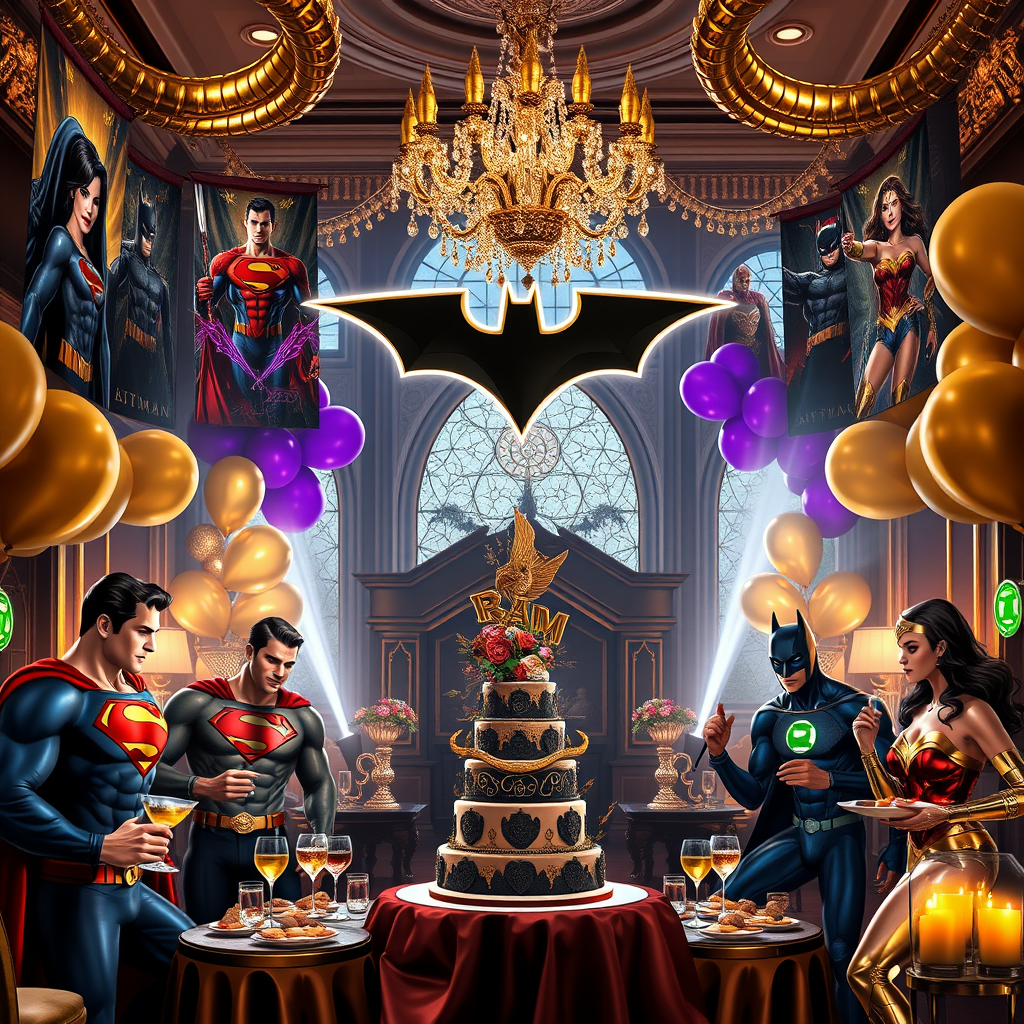

In [7]:
from IPython.display import display

display(result)

## 3. Importing a Hugging Face Space as a Tool

Hugging Face Spaces can also be integrated as tools using `Tool.from_space()`.

This allows an agent to use applications hosted on Hugging Face Spaces as part of its workflow.

In [ ]:
from smolagents import CodeAgent, InferenceClientModel, Tool

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

### Note

When attempting to import the Hugging Face Space using `Tool.from_space()`, a compatibility error occurred between the installed versions of `smolagents` and `gradio_client`.

The error was:

`TypeError: Client.__init__() got an unexpected keyword argument 'hf_token'`

The concept and implementation of `Tool.from_space()` were explored, but the Space could not be connected in the current environment due to this dependency compatibility issue.

## 4. Importing a LangChain Tool

`smolagents` can also reuse tools from the LangChain ecosystem.

Using `Tool.from_langchain()`, an existing LangChain tool can be converted into a tool that can be used by a `CodeAgent`.

In [9]:
import os

os.environ["SERPAPI_API_KEY"] = "8e927e52a491906745a62b9bde42ce072f1ddcef51fefc8d583de1450ffaf35e"

### Creating a LangChain Search Tool

In this example, a search tool from LangChain is loaded and converted into a `smolagents` compatible tool using `Tool.from_langchain()`.

In [11]:
from langchain_community.agent_toolkits.load_tools import load_tools
from smolagents import Tool

search_tool = Tool.from_langchain(
    load_tools(["serpapi"])[0]
)

/var/folders/7d/411hpqds5794_6d4kqfzcjfm0000gn/T/ipykernel_89667/2899363275.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.agent_toolkits.load_tools import load_tools


### Note

The original course code uses:

`from langchain.agents import load_tools`

However, the installed version of LangChain has changed its API, and `load_tools` is no longer available from `langchain.agents`.

This section requires adapting the example to the current LangChain version or using a compatible version of the library.

In [12]:
print(search_tool)

<smolagents.tools.Tool.from_langchain.<locals>.LangChainToolWrapper object at 0x164bb5a90>


### Creating an Agent with the LangChain Tool

The converted LangChain search tool can now be provided to a `CodeAgent`.

This allows the agent to perform web searches using the SerpAPI integration.

In [15]:
from smolagents import CodeAgent, InferenceClientModel

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct"
)

agent = CodeAgent(
    tools=[search_tool],
    model=model
)

### Running the Agent with the LangChain Tool

Now the agent is given a task that requires current web information.

The agent can use the LangChain SerpAPI search tool to search for relevant information.

In [16]:
result = agent.run(
    "Search for three luxury entertainment ideas for a superhero-themed event."
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Search for three luxury entertainment ideas for a superhero-themed event.                                       │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  entertainment_ideas = []                                                                                         
                                                                                                                   
  # Search for luxury superhero activities                                                                         
  activity_results = search(query="luxury superhero event activities")                                             
  print("Activity Results:", activity_results)                                                                     
                                                                                                                   
  # Search for luxury superhero shows                                                                              
  show_results = search(query="luxury superhero event shows")                                                      
  print("Show Results:", show_results)                                                                             
                                                                                                                   
  # Search for luxury superhero performances                                                                       
  performance_results = search(query="luxury superhero event performances")                                        
  print("Performance Results:", performance_results)                                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Activity Results: ["Unleash your team's inner heroes with the ultimate superhero-themed event experience! From 
thrilling rides and immersive attractions to all-inclusive ...", 'A heroic birthday filled with action, laughter, 
and little superheroes saving the day! lightning-fast games, 🛡 epic challenges, or 💪 superhero ...', 'Hero 
training challenges Obstacle courses Secret mission treasure hunts Design your own superhero mask Create a 
superhero badge Balloon ...', 'My soon to be 4 year old has decided she wants a superhero dance party. I plan on 
asking a friend with a cricket to add the kids names to a cape, but what ...', 'Second Annual Superhero Bash 
October 24 - 2:00 pm - 5:00 pm FREE. The community will enjoy superhero-themed fun, interactive entertainment, 
games, activities, ...', 'Meet Superheroes from Marvel or DC Comics. A Superhero party will give your guests a 
chance to let out their inner child, or show off their costuming skills.', 'The initial task is to come up with a 
superhero team name. Next, they must name each individual within the team. The last part is to draw superhero 
costumes for ...', 'Monologue Contest: Each hero/villian has to stand up and talk for at least 1 minute without 
stopping, saying about the details of how he/she ...', 'We offer several superhero party characters & affordable 
party packages.Black Panther,Superman,Wonder Woman,Iron Man party.']
Show Results: ['Join us behind the scenes as we celebrate the real superheroes of the workplace. From planning to 
execution, watch as we transform the event ...', 'From Iron Man to Bumblebee, our live character performances 
deliver thrilling action, stunning costumes, and interactive fun. Perfect for any event, we ...', 'One weekend so 
many superhero memories \u200d♂️✨❤️ GAYLORD HOTELS PRESENTS SUPER HERO SUMMER FEATURING DC HELP BATGIRL CAPTURE THE
JOKER! HELP ...', "This all new show unites some of Marvel's greatest Super Heroes including Iron Man, Captain 
America, Thor, Black Panther, Hulk and Black Widow against some ...", 'The superhero/villains events are pretty 
awesome 🙂 Now I know where this years budget went!!', 'TJH Superhero Comic Con offers fans an immersive experience
with their favorite celebrities, artists & more.', 'Join us April 15 – 17, 2026 for a spotlight on all things super
with a focus on our favorite fandom heroes from movies, television, comics, and more.', 'Meet Superheroes from 
Marvel or DC Comics. A Superhero party will give your guests a chance to let out their inner child, or show off 
their costuming skills.', 'We are the #1 Superhero Party Character Entertainment Company that specializes in Action
Superhero and Galactic Battle Stunt shows. We are unsurpassed in ...']
Performance Results: ['From Iron Man to Bumblebee, our live character performances deliver thrilling action, 
stunning costumes, and interactive fun. Perfect for any event, we ...', "We've got Spider-Man, Iron Man, and the 
Captain himself, Captain America. Bringing laughter, smiles, and unforgettable memories for your little ...", "It 
features a montage of the BMW 550e, a luxury sports car, The video highlights the luxury SUV's performance, 
high-performance luxury SUV,", 'Hip designed a multi faceted event infusing classic super hero with jaw dropping 
cirque performances. From dinner entertainment to unexpected performances ...', 'Join us behind the scenes as we 
celebrate the real superheroes of the workplace. From planning to execution, watch as we transform the event ...', 
"Our high-quality costumes and professional actors ensure that each superhero looks like they've stepped straight 
out of a comic book, ready to defend the day!", "With stunning costumes, spot-on portrayals, and engaging 
performances, it's no wonder Carbone is known for having the best superhero entertainment in the region ...", 
'Superheroes in Concert, THE AVENGERS, SPIDER-MAN, Thor, Iron Man, Captain America, Guardians of the Galaxy, 
Ant-Man, Bl

[Step 1: Duration 23.38 seconds| Input tokens: 2,081 | Output tokens: 133]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import re                                                                                                        
                                                                                                                   
  # Helper function to clean and parse results                                                                     
  def parse_results(results):                                                                                      
      parsed_list = []                                                                                             
      for result in results:                                                                                       
          # Use regex to clean up HTML codes                                                                       
          cleaned_result = re.sub(r'[^\x00-\x7F]+', '', result).replace('\\u200d♂️✨❤️', '').replace('_', ' ')       
          # Add to list                                                                                            
          parsed_list.append(cleaned_result.strip())                                                               
      return parsed_list                                                                                           
                                                                                                                   
  # Parse results                                                                                                  
  parsed_activity_results = parse_results(activity_results)                                                        
  parsed_show_results = parse_results(show_results)                                                                
  parsed_performance_results = parse_results(performance_results)                                                  
                                                                                                                   
  # Extracting three unique ideas:                                                                                 
  entertainment_ideas = set()                                                                                      
                                                                                                                   
  # Preferably we take ideas related to live appearances and shows since they align better with luxury             
  expectations                                                                                                     
  for result in parsed_show_results + parsed_activity_results + parsed_performance_results:                        
      if len(entertainment_ideas) < 3:                                                                             
          # Check if there's any mention of superheroes, live characters, or performances                          
          if "superhero" in result.lower() or "live character" in result.lower() or "performance" in               
  result.lower():                                                                                                  
              entertainment_ideas.add(result.split('.')[0])  # Adding the first sentence of each result as a       
  short idea                                                                                                       
                                                                                                                   
  # Convert set to list to maintain order                                                                          
  entertainment_ideas = list(entertainment_ideas)                                                                  
  final_answer(entertainment_ideas)                                                                                
 ───────────────────────────────────────────────────────

Final answer: []

[Step 2: Duration 7.78 seconds| Input tokens: 5,339 | Output tokens: 464]

[]


In [17]:
print(search_tool)

<smolagents.tools.Tool.from_langchain.<locals>.LangChainToolWrapper object at 0x164bb5a90>


In [18]:
result = search_tool.forward(
    {"tool_input": "luxury entertainment ideas for a superhero themed event"}
)

print(result)

['These hooks allow you to intercept tool calls, modify inputs, transform outputs, implement safety checks, and add comprehensive logging or monitoring.', 'To have Claude call a function that you define, pass a tool with an input_schema , then execute the call when Claude returns a tool_use block. How tool use ...', 'Tool Calling. As covered under Foundations, tools are objects that can be called by the model to perform a specific task. Function tools and dynamic tools ...', 'Python API reference for agents.AgentAction.tool_input in langchain_core. Part of the LangChain ecosystem. The input to pass in to the Tool .', 'tool_use : The model wants to call one or more tools. Check the tool_use block for the tool to call and any parameters. Execute. Run each ...', 'Every tool the Claw Code agent can invoke, documented from source. Covers ToolSpec schemas, input parameters, the Python tool layer, ToolPool assembly, and the ...', 'Tool calling (also known as function calling) is a common patt